In [1]:
# Making sure filepath runs smoothly
import sys
import os

print(sys.executable) 

env_root = sys.prefix

env_bin = os.path.join(env_root, "bin")
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

import rpy2.robjects as ro
from rpy2.robjects.packages import isinstalled
env_r_lib = os.path.join(env_root, "lib", "R", "library")
ro.r(f'.libPaths("{env_r_lib}")')

print("R libPaths now:")
print(ro.r(".libPaths()"))
print("phyloseq installed?", isinstalled("phyloseq"))

# imports for data analysis

# data analysis
import pandas as pd
import numpy as np
import json
import shap

# qiime and related
import qiime2
from qiime2 import Metadata, Artifact
import biom

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc, roc_auc_score, f1_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, SVR

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/bin/python
R libPaths now:
[1] "/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/R/library"

phyloseq installed? True


In [2]:
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# RF #1: All columns and age

In [3]:
# RF #1: All columns and age
# Splitting into features and targets
# Absolute
abs_X_train = (
    abs_train[abs_train.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_train['age'])
)
abs_Y_train = abs_train['sex']

abs_X_test = (
    abs_test[abs_test.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_test['age'])
)
abs_Y_test = abs_test['sex']

abs_X_val = (
    abs_val[abs_val.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_val['age'])
)
abs_Y_val = abs_val['sex']

# Absolute
rel_X_train = (
    rel_train[rel_train.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_train['age'])
)
rel_Y_train = rel_train['sex']

rel_X_test = (
    rel_test[rel_test.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=rel_test['age'])
)
rel_Y_test = rel_test['sex']

rel_X_val = (
    rel_val[rel_val.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=rel_val['age'])
)
rel_Y_val = rel_val['sex']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

Validation accuracy: 0.7370078740157481
Test accuracy: 0.7086614173228346


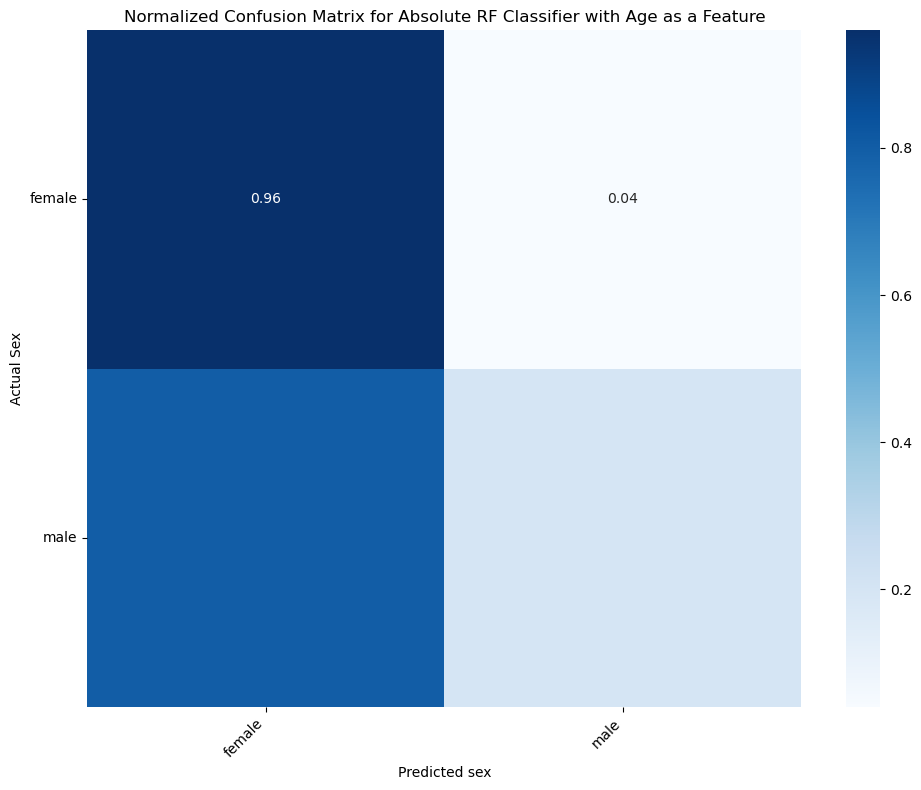

In [4]:
# Absolute
abs_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
abs_rf.fit(abs_X_train_log, abs_Y_train)

# Validation set
val_preds = abs_rf.predict(abs_X_val_log)
print("Validation accuracy:", accuracy_score(abs_Y_val, val_preds))

# Test set
test_preds = abs_rf.predict(abs_X_test_log)
abs_rf_accuracy = accuracy_score(abs_Y_test, test_preds)
print("Test accuracy:", abs_rf_accuracy)

cm = confusion_matrix(abs_Y_test, test_preds)
labels = abs_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Absolute RF Classifier with Age as a Feature")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("unbalanced_sex_abs_rf_cm.png", format="png")
plt.show()

Validation accuracy: 0.7244094488188977
Test accuracy: 0.7149606299212599


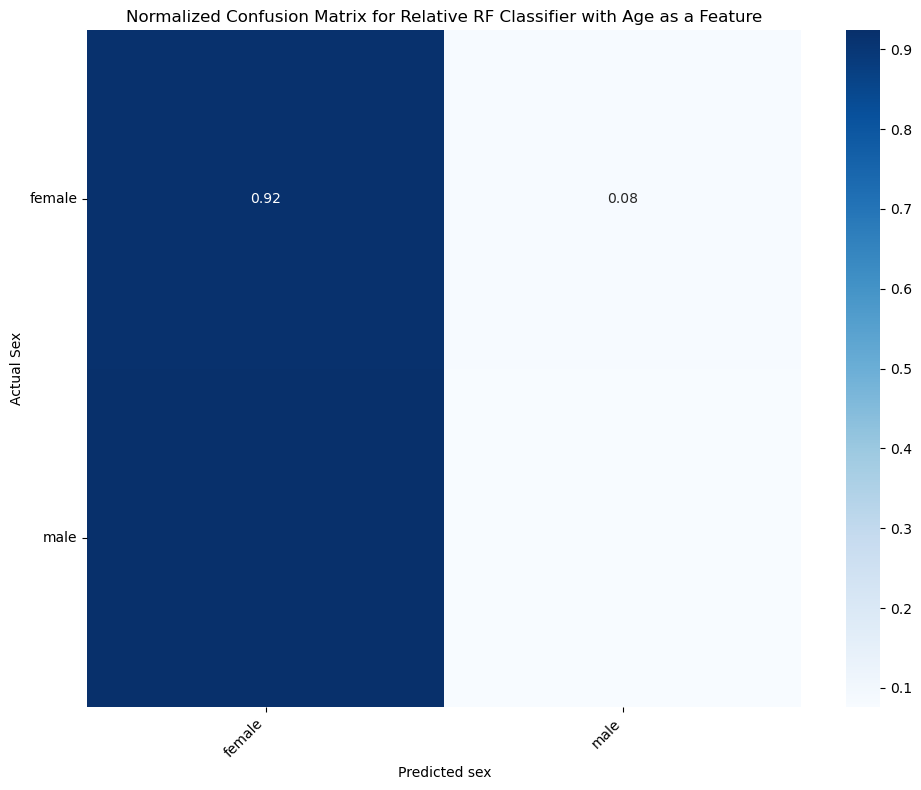

In [5]:
# Relative
rel_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf.fit(rel_X_train_log, rel_Y_train)

# Validation set
val_preds = rel_rf.predict(rel_X_val_log)
print("Validation accuracy:", accuracy_score(rel_Y_val, val_preds))

# Test set
test_preds = rel_rf.predict(rel_X_test_log)
rel_rf_accuracy = accuracy_score(rel_Y_test, test_preds)
print("Test accuracy:", rel_rf_accuracy)

cm = confusion_matrix(rel_Y_test, val_preds)
labels = abs_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Relative RF Classifier with Age as a Feature")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("unbalanced_sex_rel_rf_cm.png", format="png")
plt.show()

# Balancing the Training Set

In [6]:
# Massive sex imbalance in the training set, attempting to rebalance
# Balancing the training set
# Absolute quant
target_n = 585

abs_balanced_train = (
    abs_train
    .groupby('sex', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("sex", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# # Splitting into features and targets
# Absolute
abs_X_train = (
    abs_balanced_train[abs_balanced_train.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_balanced_train['age'])
)
abs_Y_train = abs_balanced_train['sex']

abs_X_test = (
    abs_test[abs_test.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_test['age'])
)
abs_Y_test = abs_test['sex']

abs_X_val = (
    abs_val[abs_val.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_val['age'])
)
abs_Y_val = abs_val['sex']

# Absolute
rel_X_train = (
    rel_balanced_train[rel_balanced_train.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_train['age'])
)
rel_Y_train = rel_balanced_train['sex']

rel_X_test = (
    rel_test[rel_test.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=rel_test['age'])
)
rel_Y_test = rel_test['sex']

rel_X_val = (
    rel_val[rel_val.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=rel_val['age'])
)
rel_Y_val = rel_val['sex']


# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

/tmp/ipykernel_4020/2698940189.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_4020/2698940189.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Validation accuracy: 0.6787401574803149
Test accuracy: 0.6708661417322834


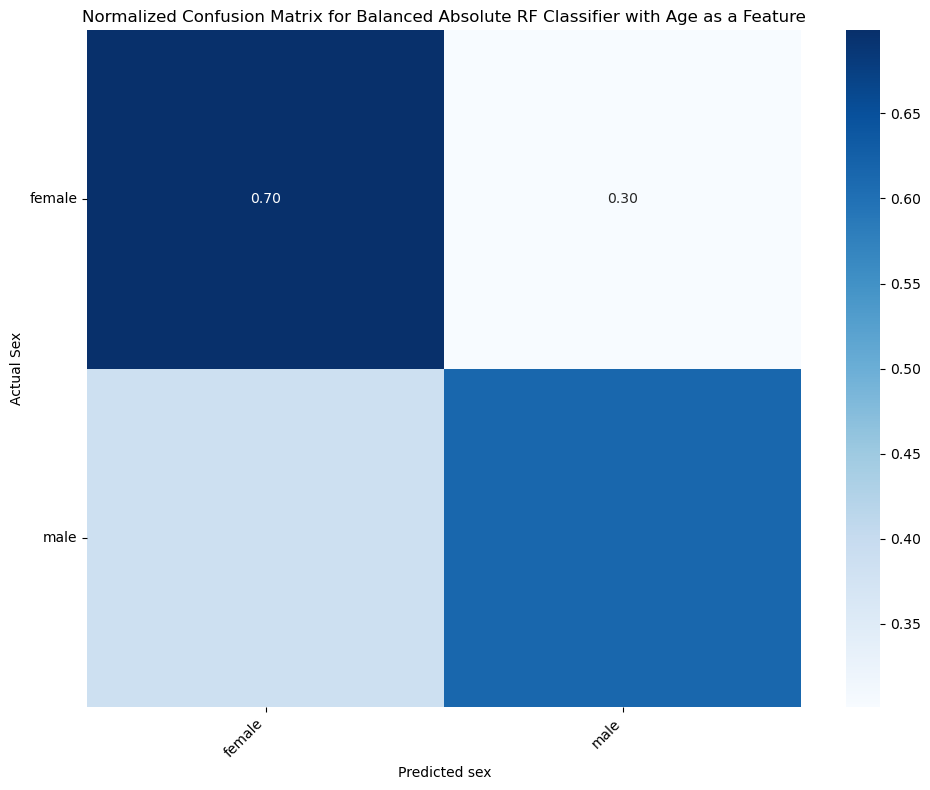

In [7]:
# Balanced absolute
abs_bal_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
abs_bal_rf.fit(abs_X_train_log, abs_Y_train)

# Validation set
val_preds = abs_bal_rf.predict(abs_X_val_log)
print("Validation accuracy:", accuracy_score(abs_Y_val, val_preds))

# Test set
test_preds = abs_bal_rf.predict(abs_X_test_log)
abs_bal_rf_accuracy = accuracy_score(abs_Y_test, test_preds)
print("Test accuracy:", abs_bal_rf_accuracy)

cm = confusion_matrix(abs_Y_test, test_preds)
labels = abs_bal_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Balanced Absolute RF Classifier with Age as a Feature")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("balanced_sex_abs_rf_cm.png", format="png")
plt.show()

Validation accuracy: 0.6913385826771653
Test accuracy: 0.7023622047244095


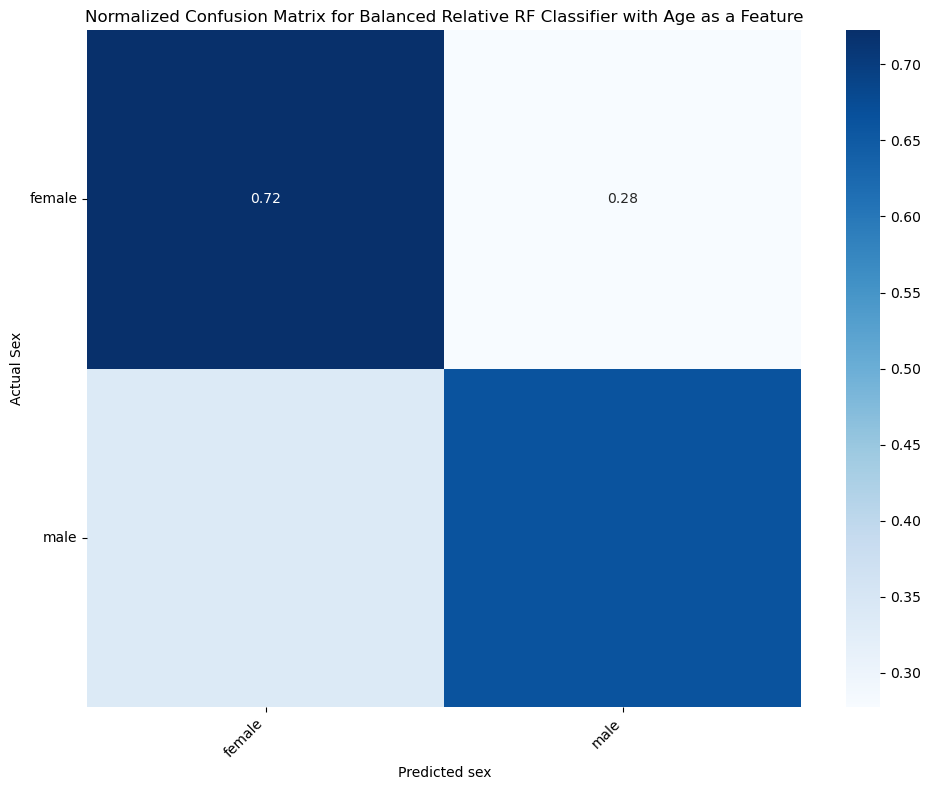

In [8]:
# Balanced relative
rel_bal_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rel_bal_rf.fit(rel_X_train_log, rel_Y_train)

# Validation set
val_preds = rel_bal_rf.predict(rel_X_val_log)
print("Validation accuracy:", accuracy_score(rel_Y_val, val_preds))

# Test set
test_preds = rel_bal_rf.predict(rel_X_test_log)
rel_bal_rf_accuracy = accuracy_score(rel_Y_test, test_preds)
print("Test accuracy:", rel_bal_rf_accuracy)

cm = confusion_matrix(rel_Y_test, test_preds)
labels = rel_bal_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Balanced Relative RF Classifier with Age as a Feature")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("balanced_sex_rel_rf_cm.png", format="png")
plt.show()

In [9]:
# Removing age as a feature
# # Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['sex']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['sex']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['sex']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['sex']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['sex']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['sex']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

Validation accuracy: 0.6818897637795276
Test accuracy: 0.6692913385826772


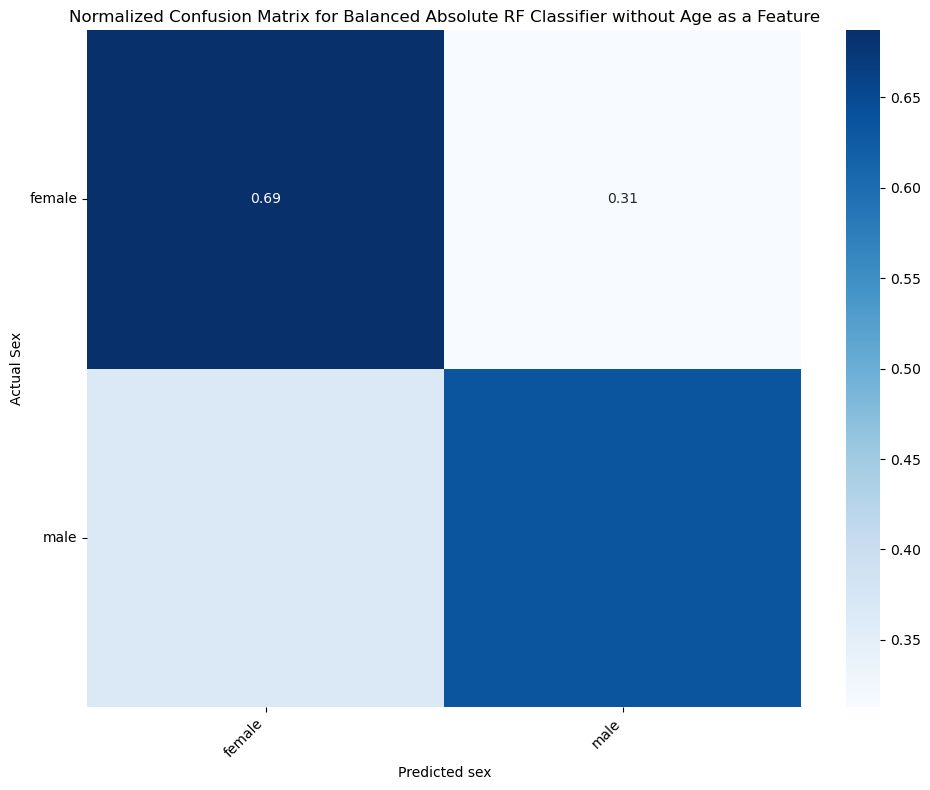

In [10]:
# Balanced absolute with no age
abs_bal_ageless_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
abs_bal_ageless_rf.fit(abs_X_train_log, abs_Y_train)

# Validation set
val_preds = abs_bal_ageless_rf.predict(abs_X_val_log)
print("Validation accuracy:", accuracy_score(abs_Y_val, val_preds))

# Test set
test_preds = abs_bal_ageless_rf.predict(abs_X_test_log)
abs_bal_ageless_rf_accuracy = accuracy_score(abs_Y_test, test_preds)
print("Test accuracy:", abs_bal_ageless_rf_accuracy)

cm = confusion_matrix(abs_Y_test, test_preds)
labels = abs_bal_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Balanced Absolute RF Classifier without Age as a Feature")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("balanced_sex_abs_rf_ageless_cm.png", format="png")
plt.show()

Validation accuracy: 0.6834645669291338
Test accuracy: 0.6992125984251969


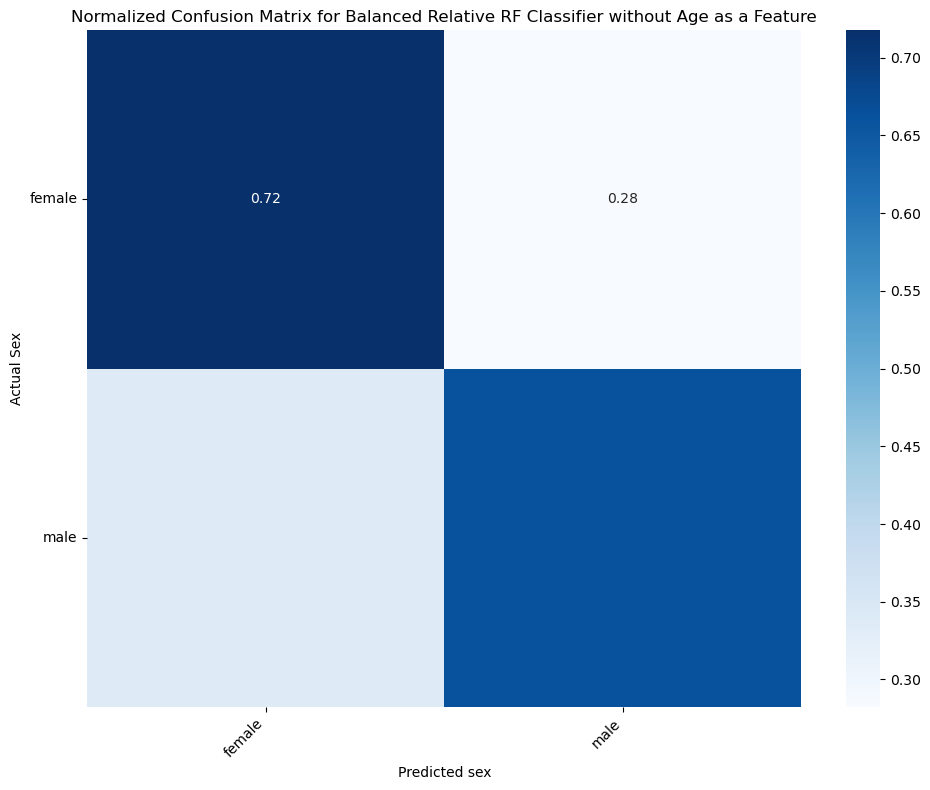

In [11]:
# Balanced relative with no age
rel_bal_ageless_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rel_bal_ageless_rf.fit(rel_X_train_log, rel_Y_train)

# Validation set
val_preds = rel_bal_ageless_rf.predict(rel_X_val_log)
print("Validation accuracy:", accuracy_score(rel_Y_val, val_preds))

# Test set
test_preds = rel_bal_ageless_rf.predict(rel_X_test_log)
rel_bal_ageless_rf_accuracy = accuracy_score(rel_Y_test, test_preds)
print("Test accuracy:", rel_bal_ageless_rf_accuracy)

cm = confusion_matrix(rel_Y_test, test_preds)
labels = abs_bal_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Balanced Relative RF Classifier without Age as a Feature")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("balanced_sex_rel_rf_ageless_cm.png", format="png")
plt.show()

# Removing columns with > 0.40 missing values

In [12]:
# Removing columns with > 0.40 missing values
threshold = 0.4
features = abs_train.columns[:1148]
frac_zeros = (abs_train[features] == 0).mean(axis=0)
keep_cols = frac_zeros[frac_zeros <= threshold].index

# # Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[keep_cols].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['sex']

abs_X_test = abs_test[keep_cols].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['sex']

abs_X_val = abs_val[keep_cols].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['sex']

# Relative abundance data
rel_X_train = rel_balanced_train[keep_cols].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['sex']

rel_X_test = rel_test[keep_cols].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['sex']

rel_X_val = rel_val[keep_cols].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['sex']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

Validation accuracy: 0.6708661417322834
Test accuracy: 0.6692913385826772


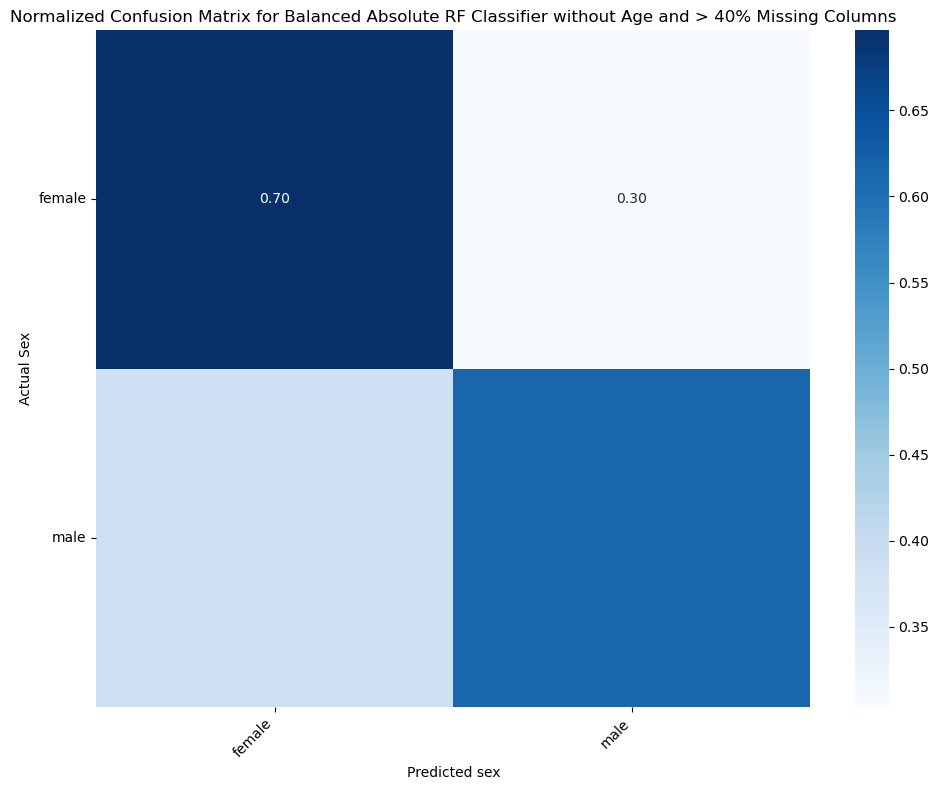

In [13]:
# Balanced absolute with no age
abs_bal_ageless_miss_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
abs_bal_ageless_miss_rf.fit(abs_X_train_log, abs_Y_train)

# Validation set
val_preds = abs_bal_ageless_miss_rf.predict(abs_X_val_log)
print("Validation accuracy:", accuracy_score(abs_Y_val, val_preds))

# Test set
test_preds = abs_bal_ageless_miss_rf.predict(abs_X_test_log)
abs_bal_ageless_miss_rf_accuracy = accuracy_score(abs_Y_test, test_preds)
print("Test accuracy:", abs_bal_ageless_rf_accuracy)

cm = confusion_matrix(abs_Y_test, test_preds)
labels = abs_bal_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Balanced Absolute RF Classifier without Age and > 40% Missing Columns")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("balanced_sex_abs_rf_ageless_miss_cm.png", format="png")
plt.show()

Validation accuracy: 0.6787401574803149
Test accuracy: 0.6992125984251969


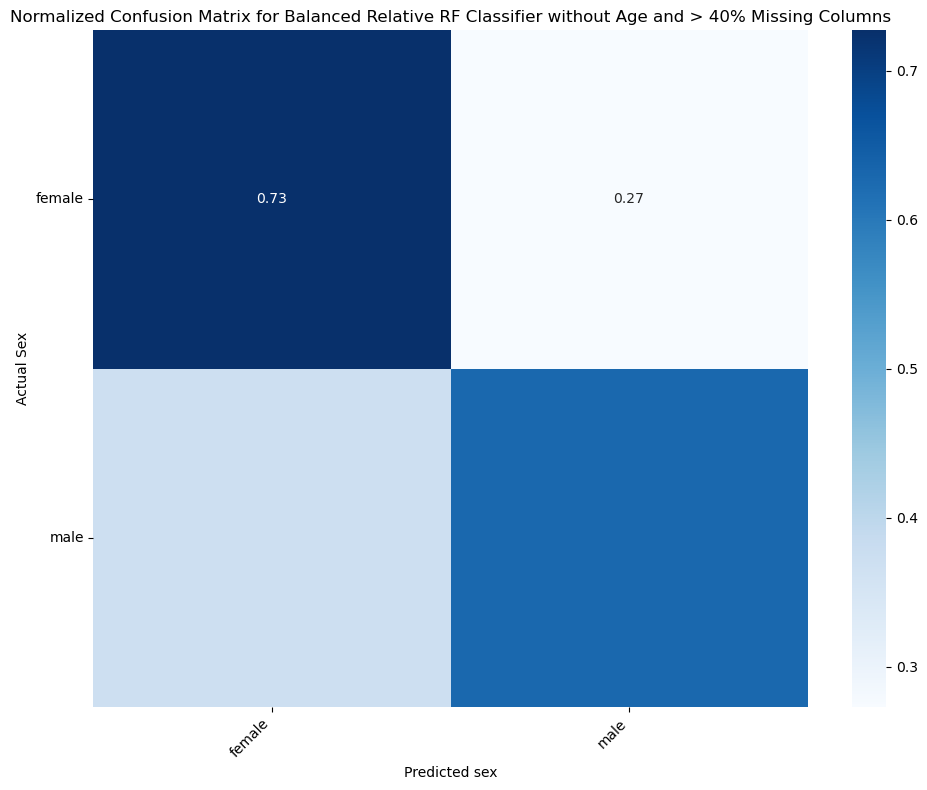

In [14]:
# Balanced relative with no age or missing columns
rel_bal_ageless_miss_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rel_bal_ageless_miss_rf.fit(rel_X_train_log, rel_Y_train)

# Validation set
val_preds = rel_bal_ageless_miss_rf.predict(rel_X_val_log)
print("Validation accuracy:", accuracy_score(rel_Y_val, val_preds))

# Test set
test_preds = rel_bal_ageless_miss_rf.predict(rel_X_test_log)
rel_bal_ageless_miss_rf_accuracy = accuracy_score(rel_Y_test, test_preds)
print("Test accuracy:", rel_bal_ageless_rf_accuracy)

cm = confusion_matrix(rel_Y_test, test_preds)
labels = abs_bal_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Balanced Relative RF Classifier without Age and > 40% Missing Columns")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("balanced_sex_rel_rf_ageless_miss_cm.png", format="png")
plt.show()

# Testing to see if our classifier is better than predicting random

In [15]:
# Testing on balanced validation/test
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Balancing the training set
# Absolute quant
target_n = 585

abs_balanced_train = (
    abs_train
    .groupby('sex', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("sex", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Balancing test
# Absolute quant
target_n = 210

abs_balanced_test = (
    abs_test
    .groupby('sex', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_test = (
    rel_test
    .groupby("sex", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Balancing validation
# Absolute quant
target_n = 196

abs_balanced_val = (
    abs_val
    .groupby('sex', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_val = (
    rel_val
    .groupby("sex", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# # Splitting into features and targets
# Absolute
abs_X_train = (
    abs_balanced_train[abs_balanced_train.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_balanced_train['age'])
)
abs_Y_train = abs_balanced_train['sex']

abs_X_bal_test = (
    abs_balanced_test[abs_balanced_test.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_test['age'])
)
abs_Y_bal_test = abs_balanced_test['sex']

abs_X_bal_val = (
    abs_balanced_val[abs_balanced_val.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=abs_val['age'])
)
abs_Y_bal_val = abs_balanced_val['sex']

# Absolute
rel_X_train = (
    rel_balanced_train[rel_balanced_train.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=rel_balanced_train['age'])
)
rel_Y_train = rel_balanced_train['sex']

rel_X_bal_test = (
    rel_balanced_test[rel_balanced_test.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=rel_test['age'])
)
rel_Y_bal_test = rel_balanced_test['sex']

rel_X_bal_val = (
    rel_balanced_val[rel_balanced_val.columns[:1148]]
        .drop(columns=['original_SampleID'])
        .assign(age=rel_val['age'])
)
rel_Y_bal_val = rel_balanced_val['sex']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_bal_log = abs_X_train.copy()
abs_X_train_bal_log = np.log1p(abs_X_train_log)

abs_X_test_bal_log = abs_X_bal_test.copy()
abs_X_test_bal_log = np.log1p(abs_X_test_bal_log)

abs_X_val_bal_log = abs_X_bal_val.copy()
abs_X_val_bal_log = np.log1p(abs_X_val_bal_log)

# Relative abundance data
rel_X_train_bal_log = rel_X_train.copy()
rel_X_train_bal_log = np.log1p(rel_X_train_log)

rel_X_test_bal_log = rel_X_bal_test.copy()
rel_X_test_bal_log = np.log1p(rel_X_test_log)

rel_X_val_bal_log = rel_X_bal_val.copy()
rel_X_val_bal_log = np.log1p(rel_X_val_bal_log)

/tmp/ipykernel_4020/639658611.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_4020/639658611.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_4020/639658611.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping 

In [16]:
abs_val_preds = abs_rf.predict(abs_X_val_bal_log)
print("val accuracy:", accuracy_score(abs_Y_bal_val, abs_val_preds))

abs_bal_val_preds = abs_bal_rf.predict(abs_X_val_bal_log)
print("val accuracy:", accuracy_score(abs_Y_bal_val, abs_bal_val_preds))

abs_X_val_bal_log_ageless = abs_X_val_bal_log.copy().drop(columns=['age'])
abs_bal_ageless_val_preds = abs_bal_ageless_rf.predict(abs_X_val_bal_log_ageless)
print("val accuracy:", accuracy_score(abs_Y_bal_val, abs_bal_ageless_val_preds))

val accuracy: 0.576530612244898
val accuracy: 0.6530612244897959
val accuracy: 0.6607142857142857


In [17]:
rel_val_preds = rel_rf.predict(rel_X_val_bal_log)
print("val accuracy:", accuracy_score(rel_Y_bal_val, rel_val_preds))

rel_bal_val_preds = rel_bal_rf.predict(rel_X_val_bal_log)
print("val accuracy:", accuracy_score(abs_Y_bal_val, abs_bal_val_preds))

rel_X_val_bal_log_ageless = rel_X_val_bal_log.copy().drop(columns=['age'])
rel_bal_ageless_val_preds = rel_bal_ageless_rf.predict(rel_X_val_bal_log_ageless)
print("val accuracy:", accuracy_score(rel_Y_bal_val, rel_bal_ageless_val_preds))

val accuracy: 0.5714285714285714
val accuracy: 0.6530612244897959
val accuracy: 0.6658163265306123


# Evaluating the Strongest Performing Model

In [18]:
print("TEST ACCURACY COMPARISON")

print(f"{'Model':<35}{'Absolute':>12}{'Relative':>12}")
print("-" * 60)

print(f"{'RF (unbalanced)':<35}"
      f"{abs_rf_accuracy:>12.4f}"
      f"{rel_rf_accuracy:>12.4f}")

print(f"{'RF (balanced)':<35}"
      f"{abs_bal_rf_accuracy:>12.4f}"
      f"{rel_bal_rf_accuracy:>12.4f}")

print(f"{'RF (balanced, no age)':<35}"
      f"{abs_bal_ageless_rf_accuracy:>12.4f}"
      f"{rel_bal_ageless_rf_accuracy:>12.4f}")

print(f"{'RF (balanced, no age/missing taxa)':<35}"
      f"{abs_bal_ageless_miss_rf_accuracy:>12.4f}"
      f"{rel_bal_ageless_miss_rf_accuracy:>12.4f}")

print("\n=====================================================\n")

TEST ACCURACY COMPARISON
Model                                  Absolute    Relative
------------------------------------------------------------
RF (unbalanced)                          0.7087      0.7150
RF (balanced)                            0.6709      0.7024
RF (balanced, no age)                    0.6693      0.6992
RF (balanced, no age/missing taxa)       0.6693      0.6945




In [19]:
# Removing age as a feature
# # Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['sex']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['sex']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['sex']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['sex']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['sex']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['sex']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

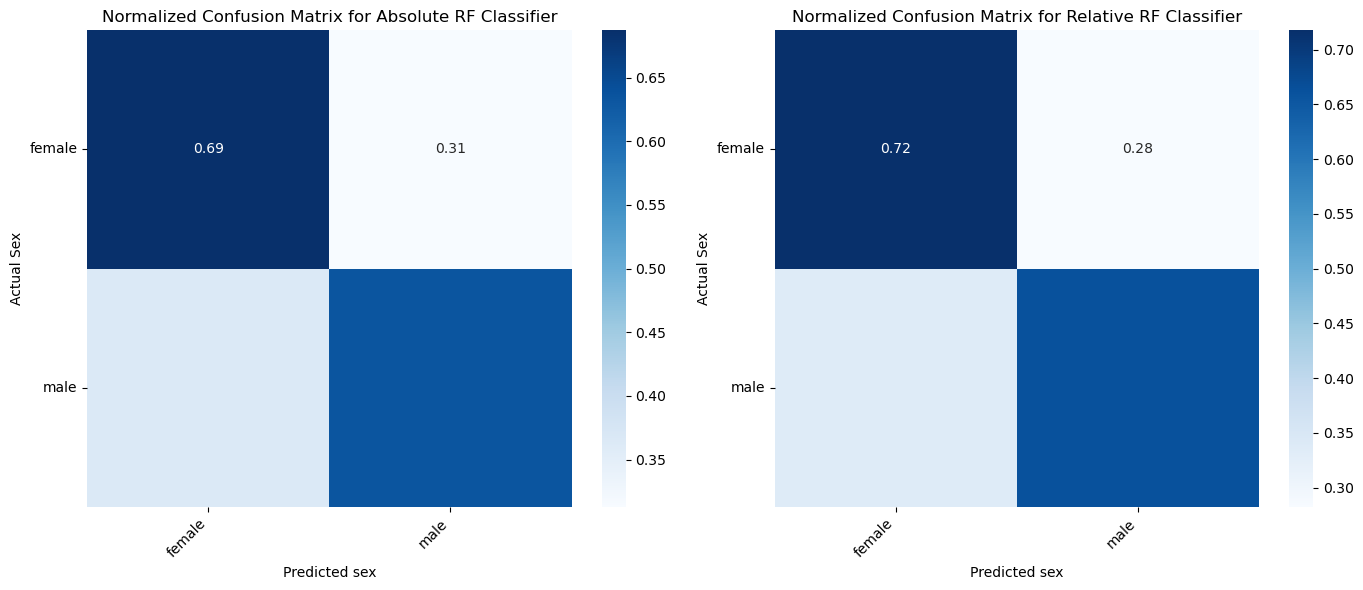

In [20]:
# Our best model is balanced with no age
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute
abs_test_preds = abs_bal_ageless_rf.predict(abs_X_test_log)
cm = confusion_matrix(abs_Y_test, abs_test_preds)
labels = abs_bal_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_xlabel("Predicted sex")
axes[0].set_ylabel("Actual Sex")
axes[0].set_xticklabels(labels, rotation=45, ha="right")
axes[0].set_yticklabels(labels, rotation=0)
axes[0].set_title("Normalized Confusion Matrix for Absolute RF Classifier")

# Relative
rel_test_preds = rel_bal_ageless_rf.predict(rel_X_test_log)
cm = confusion_matrix(rel_Y_test, rel_test_preds)
labels = rel_bal_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_xlabel("Predicted sex")
axes[1].set_ylabel("Actual Sex")
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_yticklabels(labels, rotation=0)
axes[1].set_title("Normalized Confusion Matrix for Relative RF Classifier")
plt.savefig("sex_rf_cm_comparison.png", format="png")
plt.tight_layout()
plt.show()

In [21]:
print(classification_report(abs_Y_test, abs_test_preds))
print(classification_report(rel_Y_test, rel_test_preds))

              precision    recall  f1-score   support

      female       0.79      0.69      0.74       425
        male       0.50      0.63      0.56       210

    accuracy                           0.67       635
   macro avg       0.65      0.66      0.65       635
weighted avg       0.69      0.67      0.68       635

              precision    recall  f1-score   support

      female       0.81      0.72      0.76       425
        male       0.54      0.66      0.59       210

    accuracy                           0.70       635
   macro avg       0.67      0.69      0.68       635
weighted avg       0.72      0.70      0.71       635



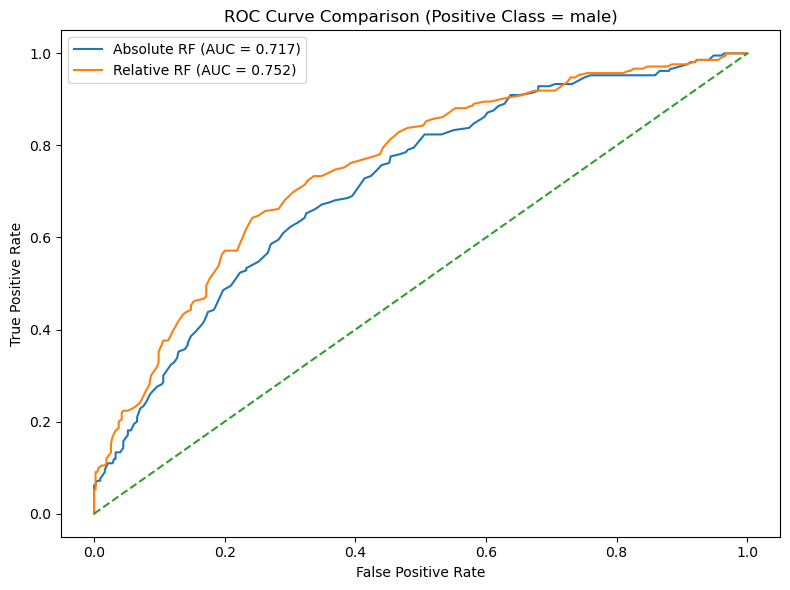

In [22]:
# Plotting the Macro-AUC
# Choosing male as the positive class
pos_class = "male"
abs_pos_index = list(abs_bal_ageless_rf.classes_).index(pos_class)
rel_pos_index = list(rel_bal_ageless_rf.classes_).index(pos_class)

abs_probs = abs_bal_ageless_rf.predict_proba(abs_X_test_log)[:, abs_pos_index]
rel_probs = rel_bal_ageless_rf.predict_proba(rel_X_test_log)[:, rel_pos_index]

abs_fpr, abs_tpr, _ = roc_curve(abs_Y_test, abs_probs, pos_label=pos_class)
rel_fpr, rel_tpr, _ = roc_curve(rel_Y_test, rel_probs, pos_label=pos_class)

abs_auc = auc(abs_fpr, abs_tpr)
rel_auc = auc(rel_fpr, rel_tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(abs_fpr, abs_tpr,
         label=f"Absolute RF (AUC = {abs_auc:.3f})")
plt.plot(rel_fpr, rel_tpr,
         label=f"Relative RF (AUC = {rel_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve Comparison (Positive Class = {pos_class})")
plt.legend()
plt.tight_layout()
plt.savefig("sex_rf_roc_comparison.png", format="png")
plt.show()

In [23]:
# Bootstrapping to see if results are significant
n_boot = 1000
rng = np.random.default_rng(42)

acc_diffs = []
auc_diffs = []

y_abs_true = abs_Y_test.to_numpy()
y_rel_true = rel_Y_test.to_numpy()

y_abs_pred = abs_bal_ageless_rf.predict(abs_X_test_log)
y_rel_pred = rel_bal_ageless_rf.predict(rel_X_test_log)

abs_y_prob = abs_bal_ageless_rf.predict_proba(abs_X_test_log)[:, 1]
rel_y_prob = rel_bal_ageless_rf.predict_proba(rel_X_test_log)[:, 1]

def stratified_bootstrap_indices(y, rng):
    indices = []
    classes = np.unique(y)

    for c in classes:
        class_idx = np.where(y == c)[0]
        boot_idx = rng.choice(class_idx, size=len(class_idx), replace=True)
        indices.extend(boot_idx)

    return np.array(indices)

# Bootstrap
for _ in range(n_boot):

    indices = stratified_bootstrap_indices(y_abs_true, rng)

    # Accuracy
    acc_abs = accuracy_score(y_abs_true[indices], y_abs_pred[indices])
    acc_rel = accuracy_score(y_rel_true[indices], y_rel_pred[indices])
    acc_diffs.append(acc_abs - acc_rel)

    # Binary AUC
    auc_abs = roc_auc_score(y_abs_true[indices], abs_y_prob[indices])
    auc_rel = roc_auc_score(y_rel_true[indices], rel_y_prob[indices])
    auc_diffs.append(auc_abs - auc_rel)

# Confidence Interval
acc_ci = np.percentile(acc_diffs, [2.5, 97.5])
auc_ci = np.percentile(auc_diffs, [2.5, 97.5])

print("Accuracy difference 95% CI (Abs - Rel):", acc_ci)
print("Macro-AUC difference 95% CI (Abs - Rel):", auc_ci)

# Interpretation
if acc_ci[0] > 0 or acc_ci[1] < 0:
    print("Accuracy difference is statistically significant.")
else:
    print("Accuracy difference is NOT statistically significant.")

if auc_ci[0] > 0 or auc_ci[1] < 0:
    print("AUC difference is statistically significant.")
else:
    print("AUC difference is NOT statistically significant.")

Accuracy difference 95% CI (Abs - Rel): [-0.06299213  0.00314961]
Macro-AUC difference 95% CI (Abs - Rel): [-0.06191989 -0.01134454]
Accuracy difference is NOT statistically significant.
AUC difference is statistically significant.


In [24]:
# Feature importance
abs_feat_importance = pd.DataFrame({
    "feature": abs_X_train_log.columns,
    "importance": abs_bal_ageless_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

rel_feat_importance = pd.DataFrame({
    "feature": rel_X_train_log.columns,
    "importance": rel_bal_ageless_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

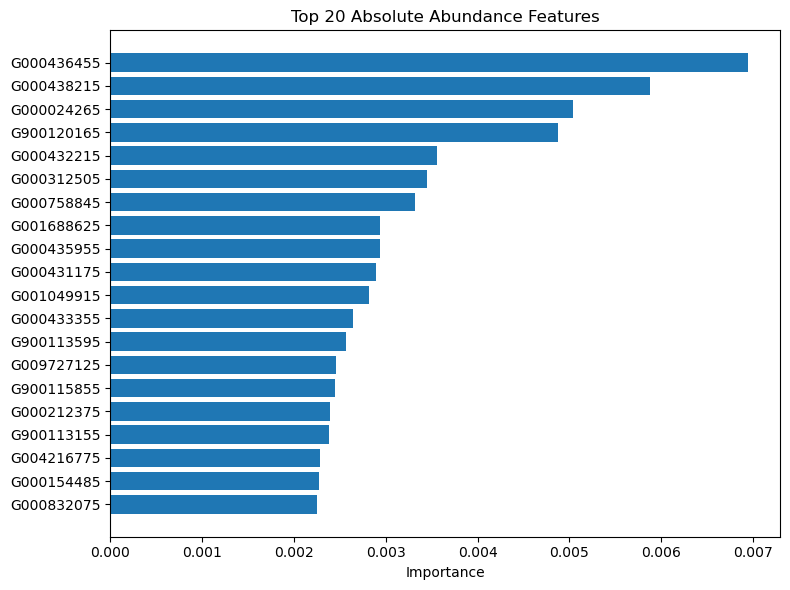

In [25]:
top_n = 20

plt.figure(figsize=(8,6))
plt.barh(
    abs_feat_importance["feature"][:top_n][::-1],
    abs_feat_importance["importance"][:top_n][::-1]
)
plt.title("Top 20 Absolute Abundance Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("sex_abs_rf_top20_features.png", format="png")
plt.show()

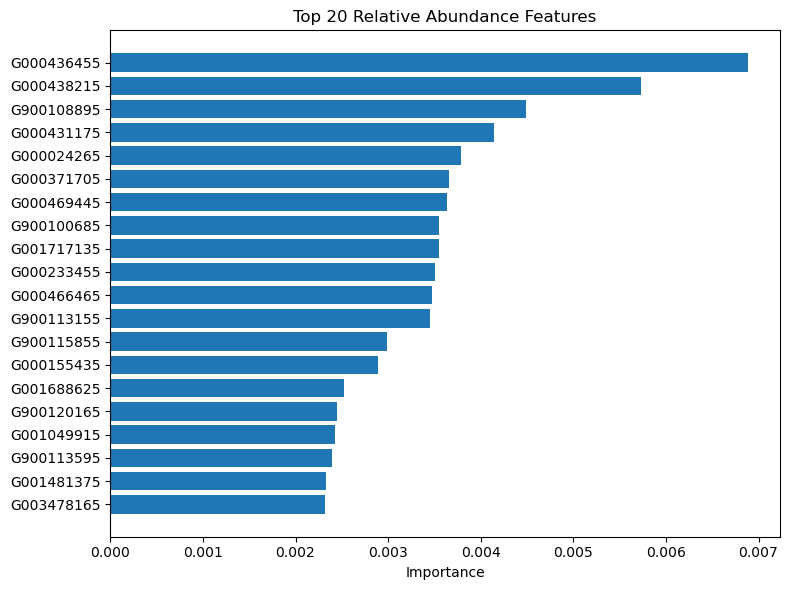

In [26]:
top_n = 20

plt.figure(figsize=(8,6))
plt.barh(
    rel_feat_importance["feature"][:top_n][::-1],
    rel_feat_importance["importance"][:top_n][::-1]
)
plt.title("Top 20 Relative Abundance Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("sex_rel_rf_top20_features.png", format="png")
plt.show()

In [27]:
# Top 20 feature names
abs_top20 = set(abs_feat_importance["feature"].head(20))
rel_top20 = set(rel_feat_importance["feature"].head(20))

overlap = abs_top20.intersection(rel_top20)
print("Overlap:", overlap)
print("Number overlapping:", len(overlap))
print("Unique to Absolute:", abs_top20 - rel_top20)
print("Unique to Relative:", rel_top20 - abs_top20)

Overlap: {'G001049915', 'G000436455', 'G001688625', 'G000431175', 'G900115855', 'G000438215', 'G900113595', 'G000024265', 'G900120165', 'G900113155'}
Number overlapping: 10
Unique to Absolute: {'G000758845', 'G004216775', 'G000212375', 'G009727125', 'G000154485', 'G000432215', 'G000435955', 'G000312505', 'G000832075', 'G000433355'}
Unique to Relative: {'G003478165', 'G000371705', 'G900108895', 'G000469445', 'G000155435', 'G900100685', 'G000233455', 'G001481375', 'G001717135', 'G000466465'}


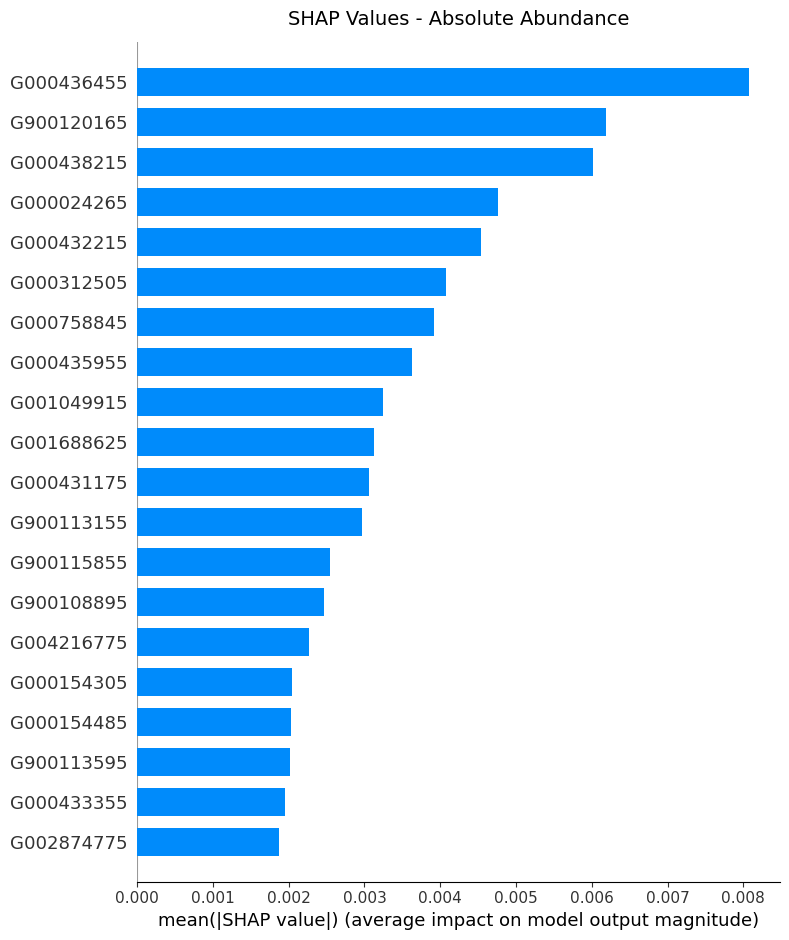

In [28]:
# SHAP Analysis
# Absolute
X = abs_X_test_log.copy()
X = X[abs_bal_ageless_rf.feature_names_in_]

abs_explainer = shap.TreeExplainer(abs_bal_ageless_rf)
abs_shap = abs_explainer(X)

sv = abs_shap.values
if sv.ndim == 3:
    class_idx = 1
    sv = sv[:, :, class_idx]

plt.figure(figsize=(8, 6))
shap.summary_plot(
    sv, X,
    plot_type="bar",
    max_display=20,
    show=False
)

ax = plt.gca()
ax.set_title("SHAP Values - Absolute Abundance", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("sex_abs_rf_shap.png", format="png")
plt.show()

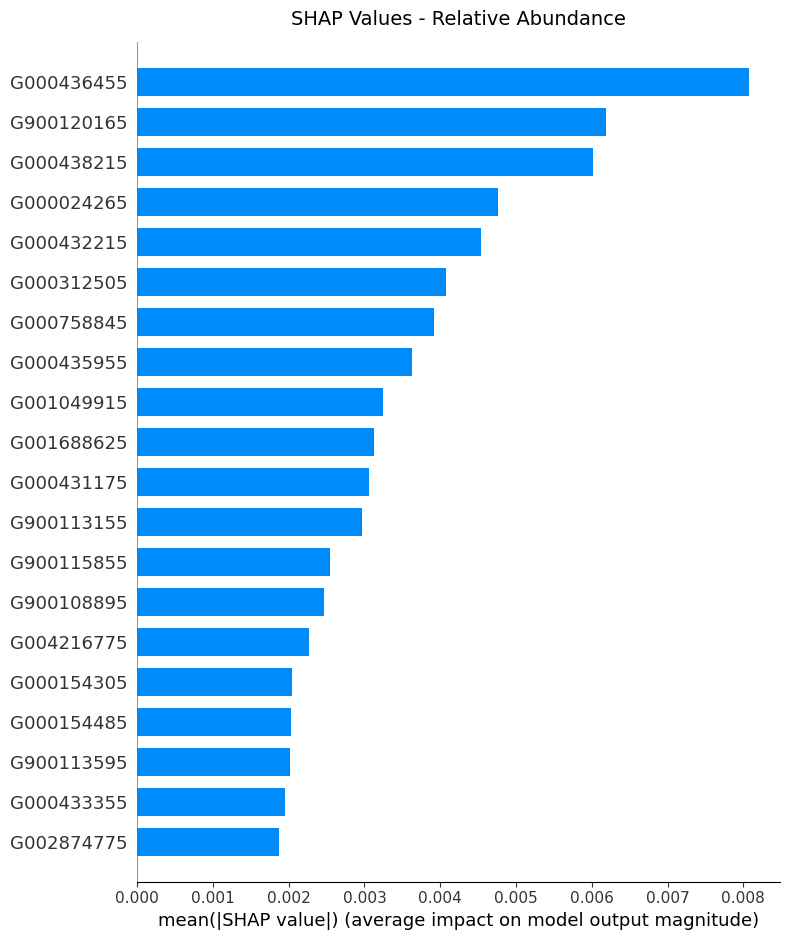

In [29]:
# Relative
X = rel_X_test_log.copy()
X = X[rel_bal_ageless_rf.feature_names_in_]

rel_explainer = shap.TreeExplainer(rel_bal_ageless_rf)
rel_shap = abs_explainer(X)

sv = abs_shap.values
if sv.ndim == 3:
    class_idx = 1
    sv = sv[:, :, class_idx]

plt.figure(figsize=(8, 6))
shap.summary_plot(
    sv, X,
    plot_type="bar",
    max_display=20,
    show=False
)

ax = plt.gca()
ax.set_title("SHAP Values - Relative Abundance", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("sex_rel_rf_shap.png", format="png")
plt.show()